Загрузим данные 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
url = "https://raw.githubusercontent.com/alexsadny/ml-course-homeworks/main/hw02_analysis_of_dataset/ev_battery_qc_data_2026_kaggle.csv"
df = pd.read_csv(url)

df.head()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,NaN,Scrap
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,NaN,NaN,Grade A
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,NaN,Routine visual inspection passed.,Grade A
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,NaN,NaN,Grade A
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,NaN,Grade A


In [2]:
df.tail()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
19995,CELL-009308,BTH-0499,Line_1,Night,VoltIndustries,20.31,0.129,14.98,14.99,4997.0,96.58,NaN,NaN,Grade A
19996,CELL-011250,BTH-0499,Line_3,Evening,VoltIndustries,21.52,0.119,14.95,14.50,5031.0,97.17,NaN,NaN,Grade B
19997,CELL-003841,BTH-0499,Line_2,Morning,ChemCorp,24.40,0.106,15.05,13.82,4993.0,97.34,NaN,NaN,Scrap
19998,CELL-000715,BTH-0499,Line_1,Evening,VoltIndustries,23.87,0.151,15.06,15.28,4970.0,97.09,High Internal Resistance,NaN,Grade B
19999,CELL-005509,BTH-0499,Line_2,Morning,ChemCorp,24.07,0.112,14.98,14.61,5014.0,95.80,NaN,NaN,Scrap


Узнаем информацию о матрице 

In [3]:
df.shape

(20000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cell_ID                   20000 non-null  str    
 1   Batch_ID                  20000 non-null  str    
 2   Production_Line           20000 non-null  str    
 3   Shift                     20000 non-null  str    
 4   Supplier                  20000 non-null  str    
 5   Ambient_Temp_C            19400 non-null  float64
 6   Anode_Overhang_mm         20000 non-null  float64
 7   Electrolyte_Volume_ml     20000 non-null  float64
 8   Internal_Resistance_mOhm  20000 non-null  float64
 9   Capacity_mAh              20000 non-null  float64
 10  Retention_50Cycle_Pct     20000 non-null  float64
 11  Defect_Type               3501 non-null   str    
 12  Inspector_Comment         1667 non-null   str    
 13  QC_Grade                  20000 non-null  str    
dtypes: float64(6), st

In [5]:
df.describe()

,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct
count,19400.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.157409,0.137498,14.979050,14.280926,4988.398450,96.801533
std,1.890930,0.020991,0.119464,0.705987,48.205605,1.170866
min,16.260000,0.057000,14.430000,11.900000,4576.000000,90.210000
25%,21.860000,0.123000,14.910000,13.790000,4971.000000,96.350000
50%,23.250000,0.138000,14.990000,14.200000,4995.000000,96.940000
75%,24.490000,0.152000,15.060000,14.680000,5017.000000,97.510000
max,29.790000,0.219000,15.370000,17.640000,5120.000000,100.840000


In [6]:
df.describe(include="object")

/var/folders/5d/1sd4b2bs3cj9zfqd1jd4w4n40000gn/T/ipykernel_12454/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Defect_Type,Inspector_Comment,QC_Grade
count,20000,20000,20000,20000,20000,3501,1667,20000
unique,20000,499,3,3,3,6,7,3
top,CELL-004920,BTH-0273,Line_1,Evening,ChemCorp,High Internal Resistance,Standard calibration OK.,Grade A
freq,1,63,8038,6768,9908,2837,311,13193


In [7]:
df.isnull().sum()

Cell_ID                         0
Batch_ID                        0
Production_Line                 0
Shift                           0
Supplier                        0
Ambient_Temp_C                600
Anode_Overhang_mm               0
Electrolyte_Volume_ml           0
Internal_Resistance_mOhm        0
Capacity_mAh                    0
Retention_50Cycle_Pct           0
Defect_Type                 16499
Inspector_Comment           18333
QC_Grade                        0
dtype: int64

Отсутствие объектов

#### Проверим тип входящих данный

In [8]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Cell_ID                         str
Batch_ID                        str
Production_Line                 str
Shift                           str
Supplier                        str
Ambient_Temp_C              float64
Anode_Overhang_mm           float64
Electrolyte_Volume_ml       float64
Internal_Resistance_mOhm    float64
Capacity_mAh                float64
Retention_50Cycle_Pct       float64
Defect_Type                     str
Inspector_Comment               str
QC_Grade                        str
dtype: object

Данные читаются правильно, повторов нет

In [11]:
df.isnull().any(axis=1).sum()

np.int64(19575)

Перейдем к обработке пропусков

In [12]:
cols = ["Inspector_Comment", "Defect_Type"]
missing = df[cols].isnull().sum()
missing_pct = df[cols].isnull().mean() * 100
pd.DataFrame({"missing": missing, "pct_missing": missing_pct})

,missing,pct_missing
Inspector_Comment,18333,91.665
Defect_Type,16499,82.495


Создаем бинарный признак наличия комментария инспектора. Это может быть информативно, так как комментарии чаще появляются при обнаружении проблем в процессе контроля качества.

In [13]:
df["has_comment"] = df["Inspector_Comment"].notna().astype(int)
# Пропущенные текстовые значения заменяем пустой строкой,
# чтобы избежать ошибок при дальнейшем анализе текста (NLP).
df["Inspector_Comment"] = df["Inspector_Comment"].fillna("")

In [14]:
df.head()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade,has_comment
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,,Scrap,0
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,NaN,,Grade A,0
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,NaN,Routine visual inspection passed.,Grade A,1
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,NaN,,Grade A,0
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,,Grade A,0


In [15]:
df["Defect_Type"].value_counts()

Defect_Type
High Internal Resistance         2837
Poor Retention                    524
Critical Resistance               117
Low Capacity                       11
Severe Capacity Fade                8
Short Circuit Risk (Overhang)       4
Name: count, dtype: int64

In [16]:
df[df["Defect_Type"].isna()]["QC_Grade"].value_counts(normalize=True)

QC_Grade
Grade A    0.751682
Grade B    0.132857
Scrap      0.115462
Name: proportion, dtype: float64

In [17]:
df[df["Defect_Type"].notna()]["QC_Grade"].value_counts(normalize=True)

QC_Grade
Grade B    0.440446
Scrap      0.333619
Grade A    0.225935
Name: proportion, dtype: float64

Строки, где Defect_Type заполнен, намного чаще получают низкие оценки (B / Scrap). В строках с пропусками Defect_Type значительно больше Grade A. Это очень сильно подтверждает гипотезу: NaN в Defect_Type скорее всего означает отсутствие найденного дефекта.

In [18]:
df["Defect_Type"]=df["Defect_Type"].fillna("No defect")

In [19]:
df.head()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade,has_comment
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,,Scrap,0
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,No defect,,Grade A,0
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,No defect,Routine visual inspection passed.,Grade A,1
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,No defect,,Grade A,0
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,,Grade A,0


#### Метод dropna() не подходит для данного датасета
Слишком много пропусков значений приведет к удалению большинства строк, от этих аномалий будем избавляться по-другому

В датасете наблюдаются пропуски как в числовых, так и в категориальных признаках.
Для числовых признаков использовались стратегии заполнения средним и медианой,
для категориальных — модой или константой.
Текстовые поля заполнялись пустой строкой, чтобы сохранить структуру данных.

In [20]:
df["Shift"].mode()[0]

'Evening'

Для категориальных переменных пропуски могут быть заполнены модой — наиболее часто встречающимся значением. Однако данный метод не всегда корректен. Например, для переменной Defect_Type пропуски вероятно означают отсутствие дефекта, поэтому вместо моды было использовано значение "No defect". </br>
В колонке Shift пропущенные значения отсутствуют, поэтому заполнение модой не потребовалось. Однако метод был рассмотрен как одна из возможных стратегий обработки пропусков

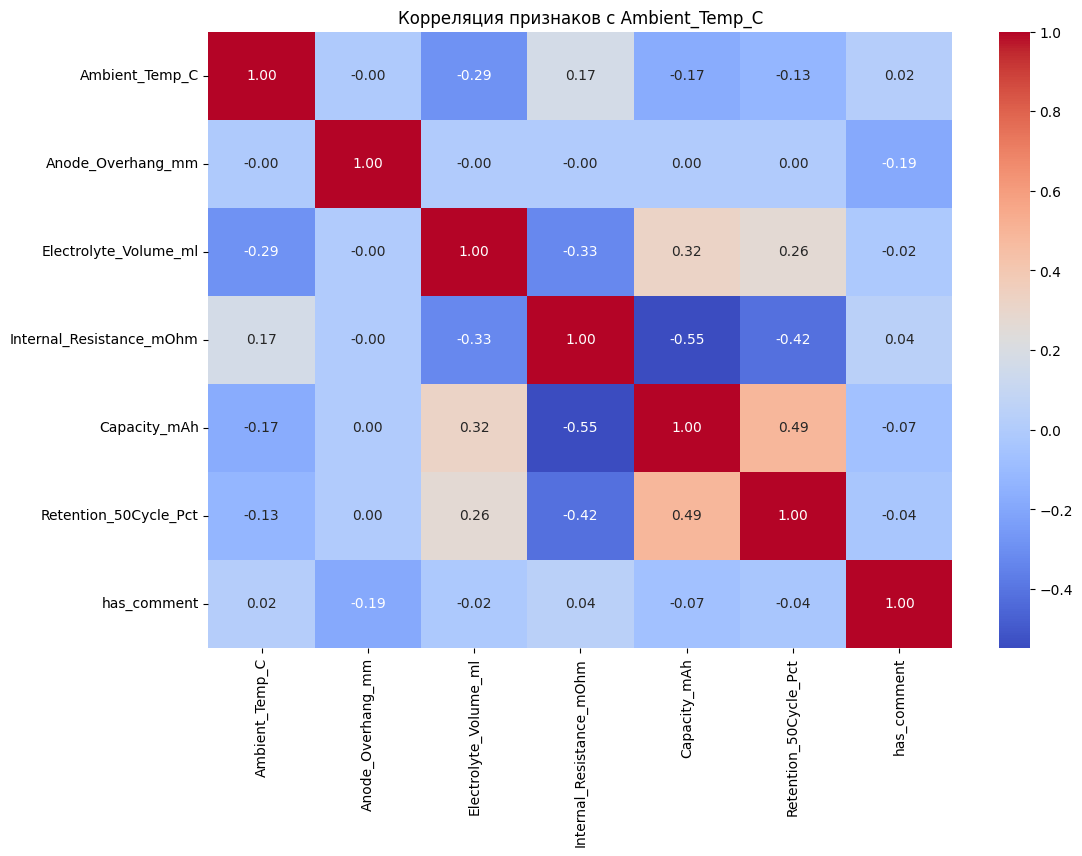

In [21]:
# Выберем только числовые признаки для матрицы корреляции
numeric_df = df.select_dtypes(include=[np.number])

# 2. Построение тепловой карты корреляций
plt.figure(figsize=(12, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция признаков с Ambient_Temp_C')
plt.show()


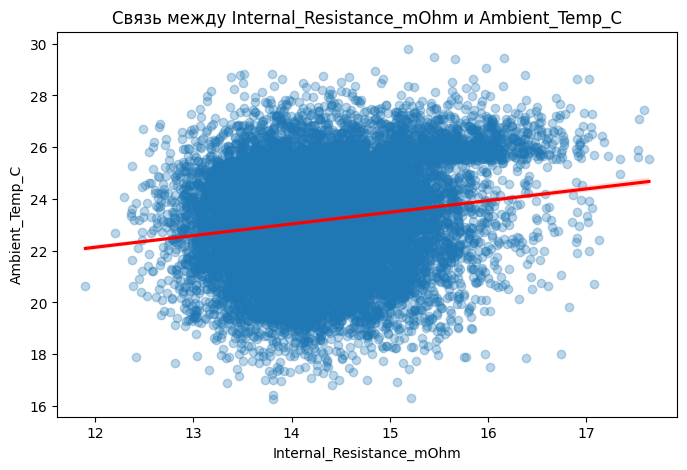

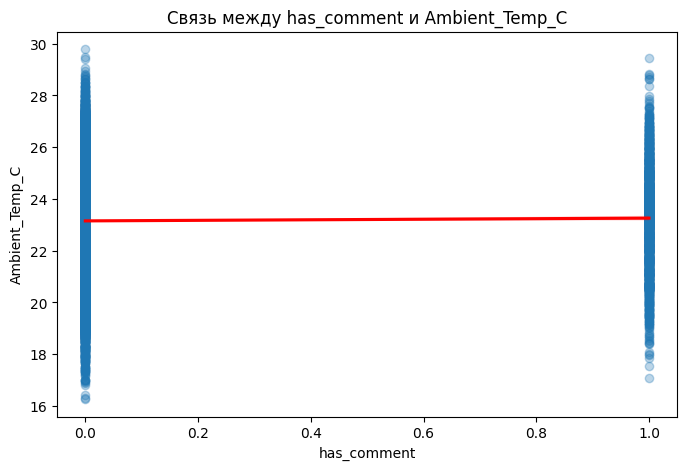

In [22]:
# 3. Визуализация связи с наиболее важными признаками
# Обычно это Internal_Resistance_mOhm или Charging_Efficiency_Pct
top_corr_features = correlation_matrix['Ambient_Temp_C'].sort_values(ascending=False).index[1:3]

for feature in top_corr_features:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x=feature, y='Ambient_Temp_C', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'Связь между {feature} и Ambient_Temp_C')
    plt.show()


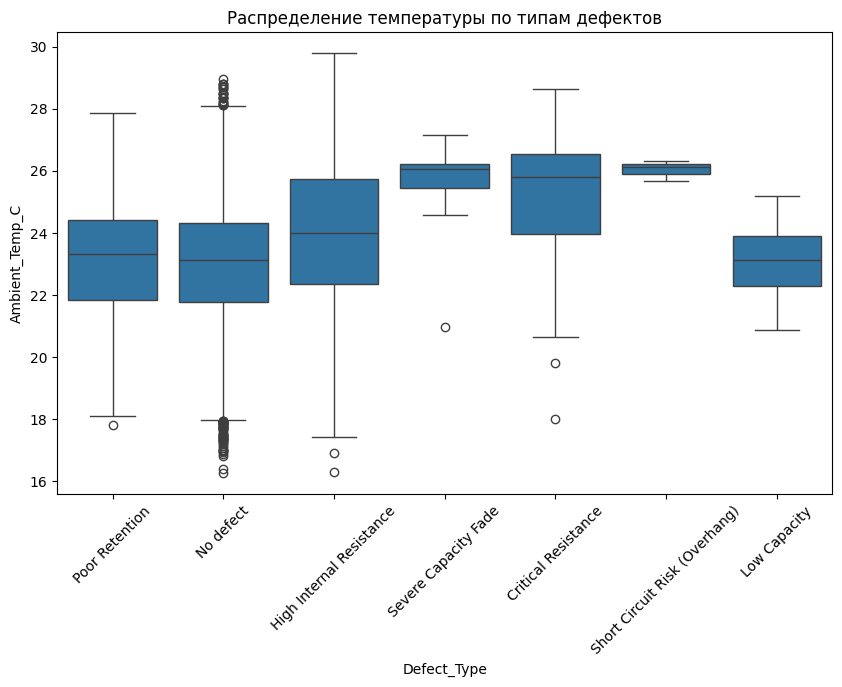

In [23]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='Defect_Type', y='Ambient_Temp_C', data=df)
plt.title('Распределение температуры по типам дефектов')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Ambient_Temp_C', ylabel='Count'>

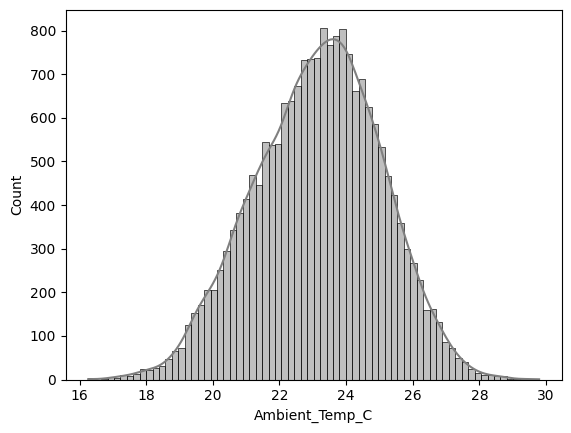

In [24]:
# Гистограмма ДО заполнения
sns.histplot(df['Ambient_Temp_C'], kde=True, color='gray', label='До заполнения', alpha=0.5)

In [25]:
print(df.groupby('Defect_Type')['Ambient_Temp_C'].agg(['mean', 'median', 'std']))

                                    mean  median       std
Defect_Type                                               
Critical Resistance            25.230783  25.810  1.970482
High Internal Resistance       23.906806  23.990  2.144997
Low Capacity                   23.010000  23.120  1.304539
No defect                      23.014373  23.130  1.805658
Poor Retention                 23.090632  23.305  1.785183
Severe Capacity Fade           25.402500  26.045  1.938761
Short Circuit Risk (Overhang)  26.036667  26.120  0.342685


In [26]:
df['Ambient_Temp_C'] = df['Ambient_Temp_C'].fillna(
    df.groupby('Defect_Type')['Ambient_Temp_C'].transform('median')
)

In [27]:
df['Ambient_Temp_C'].isna().sum()

np.int64(0)

В данных с высоким std (как у нас — до 2.14) часто бывают выбросы. Медиана гораздо устойчивее к ним: если в группе затесался один ошибочный замер в 100, среднее улетит вверх, а медиана останется спокойной.

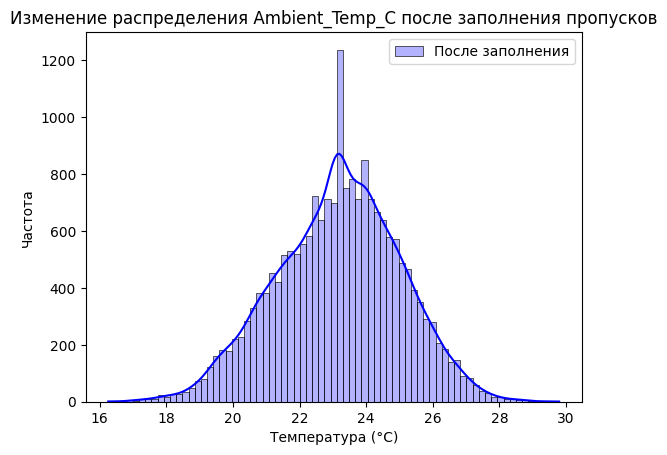

In [28]:
# Гистограмма ПОСЛЕ заполнения
sns.histplot(df['Ambient_Temp_C'], kde=True, color='blue', label='После заполнения', alpha=0.3)

plt.title('Изменение распределения Ambient_Temp_C после заполнения пропусков')
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')
plt.legend()
plt.show()

In [29]:

# 1. Выбираем только числовые колонки
numeric_cols = df.select_dtypes(include=['number'])

# 2. Основная статистика: min, max, mean, median и квантили (25, 50, 75)
# median — это и есть 50-й перцентиль (0.50)
stats = numeric_cols.describe(percentiles=[.05, .25, .5, .75, .95]).T

# 3. Добавляем моду (mode)
# Так как у столбца может быть несколько мод, берем первую [0]
stats['mode'] = numeric_cols.apply(lambda x: x.mode()[0] if not x.mode().empty else None)

# 4. Переименовываем для наглядности и выводим нужный порядок
stats = stats.rename(columns={'50%': 'median'})
columns_to_show = ['min', 'max', 'mean', 'median', 'mode', '5%', '25%', '75%', '95%']

print("Детальная статистика числовых признаков:")
print(stats[columns_to_show])

Детальная статистика числовых признаков:
                               min       max         mean    median      mode  \
Ambient_Temp_C              16.260    29.790    23.160946    23.200    23.130   
Anode_Overhang_mm            0.057     0.219     0.137498     0.138     0.132   
Electrolyte_Volume_ml       14.430    15.370    14.979050    14.990    15.000   
Internal_Resistance_mOhm    11.900    17.640    14.280926    14.200    14.170   
Capacity_mAh              4576.000  5120.000  4988.398450  4995.000  5006.000   
Retention_50Cycle_Pct       90.210   100.840    96.801533    96.940    96.890   
has_comment                  0.000     1.000     0.083350     0.000     0.000   

                                5%       25%        75%       95%  
Ambient_Temp_C              19.950    21.910    24.4425    26.130  
Anode_Overhang_mm            0.103     0.123     0.1520     0.172  
Electrolyte_Volume_ml       14.770    14.910    15.0600    15.160  
Internal_Resistance_mOhm    13.280    

Есть аномалии, в реальном мире батарея не может сохранить больше 100% изначальной емкости после 50 циклов зарядки/разрядки

In [30]:
le_target = LabelEncoder()
df['QC_Grade_Num'] = le_target.fit_transform(df['QC_Grade'])

# Посмотрим соответствие: какая цифра какому грейду соответствует
mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print("Словарь грейдов:", mapping)

Словарь грейдов: {'Grade A': np.int64(0), 'Grade B': np.int64(1), 'Scrap': np.int64(2)}


In [31]:

df_encoded = pd.get_dummies(df, columns=['Defect_Type'], drop_first=False)

# pd.get_dummies по умолчанию создает булевы значения (True/False). 
# Переведем их в 1/0 
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

print("\n--- ДАТАФРЕЙМ ПОСЛЕ КОДИРОВАНИЯ (Первые 3 строки) ---")
display(df_encoded.head(3))


one_hot_cols = [col for col in df_encoded.columns if 'Defect_Type_' in col]
print("\nСозданные One-Hot колонки:")
print(one_hot_cols)


--- ДАТАФРЕЙМ ПОСЛЕ КОДИРОВАНИЯ (Первые 3 строки) ---


,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,...,QC_Grade,has_comment,QC_Grade_Num,Defect_Type_Critical Resistance,Defect_Type_High Internal Resistance,Defect_Type_Low Capacity,Defect_Type_No defect,Defect_Type_Poor Retention,Defect_Type_Severe Capacity Fade,Defect_Type_Short Circuit Risk (Overhang)
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,...,Scrap,0,2,0,0,0,0,1,0,0
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,...,Grade A,0,0,0,0,0,1,0,0,0
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,...,Grade A,1,0,0,0,0,1,0,0,0



Созданные One-Hot колонки:
['Defect_Type_Critical Resistance', 'Defect_Type_High Internal Resistance', 'Defect_Type_Low Capacity', 'Defect_Type_No defect', 'Defect_Type_Poor Retention', 'Defect_Type_Severe Capacity Fade', 'Defect_Type_Short Circuit Risk (Overhang)']


In [32]:
# --- 1. FEATURE ENGINEERING ---

# Фича 1: Отношение сопротивления к емкости. 
# Чем выше сопротивление при низкой емкости, тем хуже состояние батареи.
df['Resist_to_Cap_Ratio'] = df['Internal_Resistance_mOhm'] / df['Capacity_mAh']

# Фича 2: Флаг критического сопротивления (используем твой 95% перцентиль: 15.59)
df['is_high_resistance'] = (df['Internal_Resistance_mOhm'] > 15.59).astype(int)

# Фича 3: Флаг критического падения емкости (используем твой 5% перцентиль: 4904)
df['is_low_capacity'] = (df['Capacity_mAh'] < 4904).astype(int)

print("--- ДАТАФРЕЙМ ДО КОДИРОВАНИЯ (Первые 3 строки) ---")
display(df.head(3))

--- ДАТАФРЕЙМ ДО КОДИРОВАНИЯ (Первые 3 строки) ---


,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade,has_comment,QC_Grade_Num,Resist_to_Cap_Ratio,is_high_resistance,is_low_capacity
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,,Scrap,0,2,0.002813,0,0
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,No defect,,Grade A,0,0,0.002946,0,0
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,No defect,Routine visual inspection passed.,Grade A,1,0,0.002742,0,0


# Заключение по итогам разведочного анализа (EDA)

В ходе работы над датасетом контроля качества (QC) литий-ионных аккумуляторов был проведен комплексный разведочный анализ данных. Результаты EDA определили стратегию предобработки для дальнейшего машинного обучения.

### 1. Обработка пропущенных значений
* **Анализ:** Были выявлены пропуски в колонке `Ambient_Temp_C`. Исследование корреляций показало слабую линейную связь ($|r| < 0.3$) температуры с сопротивлением и емкостью, что исключило использование регрессионных моделей для восстановления.
* **Решение:** Пропуски заполнены **групповой медианой** на основе `Defect_Type`. Визуализация через *Boxplot* подтвердила, что медианная температура значимо различается для разных типов дефектов. Это позволило сохранить физическую логику данных.

### 2. Визуализация и статистический анализ
* **Корреляции:** С помощью тепловой карты (`Heatmap`) и графиков рассеяния (`Scatter Plot`) подтверждено отсутствие сильных линейных зависимостей, что характерно для сложных физических систем.
* **Перцентили:** Расчет **5% и 95% перцентилей** позволил математически обосновать границы "нормального" поведения батарей. Значения за этими пределами (например, сопротивление > 15.59 мОм) были идентифицированы как потенциальные признаки брака.

### 3. Инженерия признаков и кодирование категорий
* **Feature Engineering:** Создан производный признак `Resist_to_Cap_Ratio` (отношение сопротивления к емкости), который лучше разделяет качественные и дефектные ячейки.
* **One-Hot Encoding:** Категориальный признак `Defect_Type` преобразован в бинарные колонки через `pd.get_dummies`. Это исключило навязывание ложного порядка между типами дефектов.
* **Label Encoding:** Целевая переменная `QC_Grade` закодирована числовыми метками (0, 1, 2), что является необходимым условием для большинства алгоритмов классификации.

---
**Итог:** В результате проделанной работы данные полностью очищены, структура распределений сохранена, а признаки подготовлены к этапу масштабирования и обучения моделей.